In [1]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use('science')

import numpy as np
from scipy.optimize import bisect

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from pycbc.psd.analytical import aLIGO140MpcT1800545

from scipy.differentiate import derivative

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
import sys
sys.path.insert(1, '../../detectability')

import resonance
from resonance import Filter, phase_diff_t_shift, phase_shift #System, 

In [3]:
import os

figures_path = '../figures/II'
os.makedirs(figures_path, exist_ok=True) 

In [4]:
filt = Filter(15, 1024, 512, 4096, 100, 'IMRPhenomD', 'aLIGO/AplusDesign') #f_low, f_high, tlen, srate, dL, approximant, detector

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [5]:
def error_plot(error, fres_arr, dPsi):
    dx_arr = filt.dx_fres_fix_error(error, fres_arr, dPsi)
    plt.yscale('log')
    dx_plot = plt.plot(fres_arr, -dx_arr, label= f'Error of {100*error} $\%$')

<>:4: SyntaxWarning: invalid escape sequence '\%'
<>:4: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_16455/1282381908.py:4: SyntaxWarning: invalid escape sequence '\%'
  dx_plot = plt.plot(fres_arr, -dx_arr, label= f'Error of {100*error} $\%$')


In [6]:
length_arr = 21
fres_arr = np.linspace(30, 500, length_arr) #fres=30 too much wiggling. It is difficult to find roots

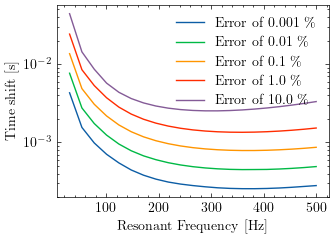

In [8]:
plt.figure(figsize=(3.5, 2.5))
[error_plot(error, fres_arr, phase_diff_t_shift) for error in [1e-5,1e-4,1e-3,1e-2,1e-1]]

#plt.title('Time shift for different errors')
plt.xlabel('Resonant Frequency [Hz]')
plt.ylabel('Time shift [s]')
plt.legend()
plt.savefig(os.path.join(figures_path, f'error_time_shift.png'), bbox_inches='tight', dpi=300)

plt.show()

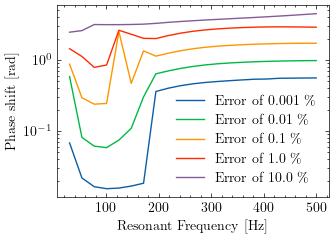

In [ ]:
plt.figure(figsize=(3.5, 2.5))#markdown

[error_plot(error, fres_arr, phase_shift) for error in [1e-5,1e-4,1e-3,1e-2,1e-1]]

#plt.title('Phase shift for different errors')
plt.xlabel('Resonant Frequency [Hz]')
plt.ylabel('Phase shift [rad]')
plt.legend()
plt.savefig(os.path.join(figures_path, f'error_phase_shift.png'), bbox_inches='tight', dpi=300)

plt.show()